Language: German

Corpus name: Leipzig Corpora Collection - German Wikipedia 2021

Corpus URL: https://wortschatz.uni-leipzig.de/en/download/German

In [7]:
%pip install nltk matplotlib wordcloud
import nltk
import matplotlib
import matplotlib.pyplot as plt
import wordcloud

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import re
with open("deu_wikipedia_2021_100K-sentences.txt", "r", encoding="utf-8") as file:
    text=file.read()
text = re.sub(r'https?://\S+|www\.\S+', '', text) # Removes URLs
text_clean = re.sub(r'\d+|[^a-zA-ZäöüÄÖÜß\s]', '', text.lower()) # Preprocessing, removing numbers, spaces, ect.
#print(text_clean)

Calculating the lexical richness of the selected corpus.

In [75]:
from nltk.tokenize import word_tokenize
words=word_tokenize(text_clean, language="german")
#print(words[0:50])
vocab=set(words)
lex_richness=len(vocab)/len(words)
print(f"Lexical Richness: {lex_richness}")

Lexical Richness: 0.11850286429303623


Plotting the character distribution of selected corpus.

Text(0.5, 1.0, 'Character Disturbution')

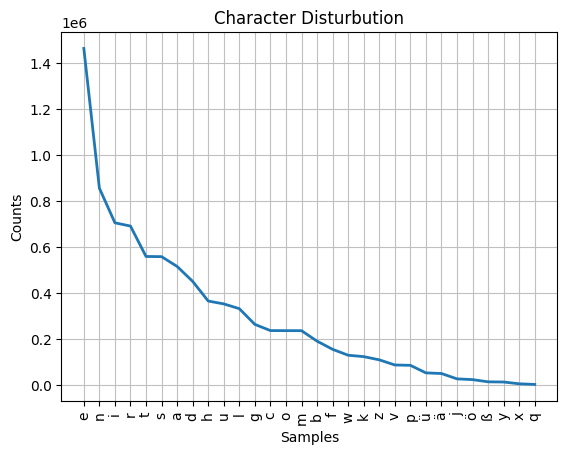

In [76]:
fdist = nltk.FreqDist(ch.lower() for ch in text_clean if ch.isalpha())
#print(fdist.most_common(10))
plot = fdist.plot()
plt.title("Character Disturbution")

Plotting the word distribution of the 20 most often used words of selected corpus (with stopwords).

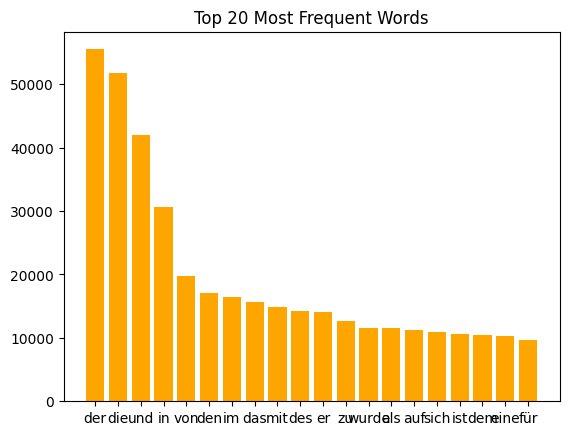

In [77]:
from collections import Counter
word_count=Counter(words)
#print(word_count)
wordsfd = nltk.FreqDist(words)
#print(wordsfd.most_common(20))
wordsmc=wordsfd.most_common(20)
labels = [word for word, freq in wordsmc]
values = [freq for word, freq in wordsmc]
plt.bar(labels, values, color='orange')
plt.title("Top 20 Most Frequent Words")
plt.show()

Plotting the dispersion plot of the 5 most often used words.

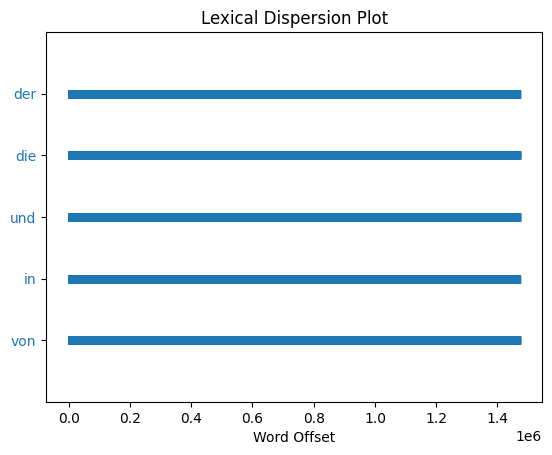

In [78]:
text2=nltk.Text(words)
plot=text2.dispersion_plot([word for word, _ in wordsmc[:5]])


Finding the longest word in the text. Selecting an algorithm for splitting words (also called word break / split algorithm) and spliting the word into subwords.

In [ ]:
longest_word=max(words, key=len)
print(f"Longest word: {longest_word}")

dictionary = set(nltk_words.words())

def split_word(words, vocab):
    result = []
    i = 0
    while i < len(word):
        for j in range(len(word), i, -1):
            piece = word[i:j].lower()
            if piece in vocab:
                result.append(piece)
                i = j
                break
        else:
            result.append(words[i])
            i += 1
    return result


subwords = split_word(longest_word, dictionary)
print("Split subwords:", subwords)

Longest word: computerunterstütztesbörsenhandelsundentscheidungssystem


Find a short sentence with 5 words (plus/minus 1). Create a context-free grammar for the sentence. The grammar shall show the syntactical structure of the sentence, so the terminal symbols shall be words.

In [100]:

sentences = nltk.sent_tokenize(text, language='german')
short_sentences = []

for s in sentences:
    words = nltk.word_tokenize(s, language='german')
    if 4 <= len(words) <= 6:
        short_sentences.append(words)


selected_sentence = short_sentences[43]
print(" Selected sentence:", " ".join(selected_sentence))

 Selected sentence: 1615 Alles bleibt beim alten .


Select a suitable stemmer and stem every word in the sentence found in last part.

In [ ]:
from nltk.stem.snowball import GermanStemmer

stemmer = GermanStemmer()

print("Stemming results:")
for word in selected_sentence:
    stem = stemmer.stem(word)
    print(f"{word} → {stem}")


Stemming results:
1615 → 1615
Alles → all
bleibt → bleibt
beim → beim
alten → alt
. → .


Find a lemmatizer for the language and lemmatize every word in the sentence.

In [ ]:
import spacy

# Load German language model
nlp = spacy.load("de_core_news_sm")
sentence_text = ' '.join(selected_sentence)
doc = nlp(sentence_text)
print("Lemmatized Words:")
for word in doc:
    print(f"{word.text} → {word.lemma_}")



Lemmatized Words:
1615 → 1615
Alles → alle
bleibt → bleiben
beim → bei
alten → alt
. → --


Remove stopwords and repeat exercises 6+7 (word distribution and dispersion plot).

[('wurde', 11564), ('wurden', 3809), ('jahr', 2654), ('zwei', 2420), ('seit', 2180), ('jahre', 2127), ('ab', 2085), ('jedoch', 2021), ('jahren', 1861), ('mehr', 1731), ('zeit', 1731), ('ersten', 1613), ('sowie', 1594), ('drei', 1555), ('s', 1457), ('später', 1376), ('etwa', 1370), ('dabei', 1348), ('bereits', 1317), ('heute', 1304)]


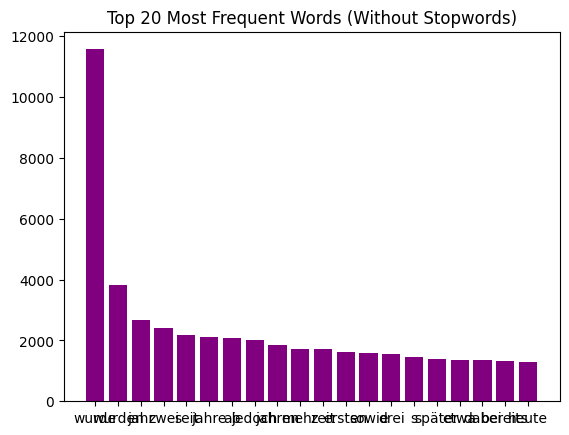

In [80]:
from nltk.corpus import stopwords
from collections import Counter

german_stopwords=set(stopwords.words('german'))
#print(german_stopwords)
filter_words=[word for word in words if word not in german_stopwords]

word_count=Counter(filter_words)
wordsfd = nltk.FreqDist(filter_words)
print(wordsfd.most_common(20))
wordsmc=wordsfd.most_common(20)
labels = [word for word, freq in wordsmc]
values = [freq for word, freq in wordsmc]
plt.bar(labels, values, color='purple')
plt.title("Top 20 Most Frequent Words (Without Stopwords)")
plt.show()

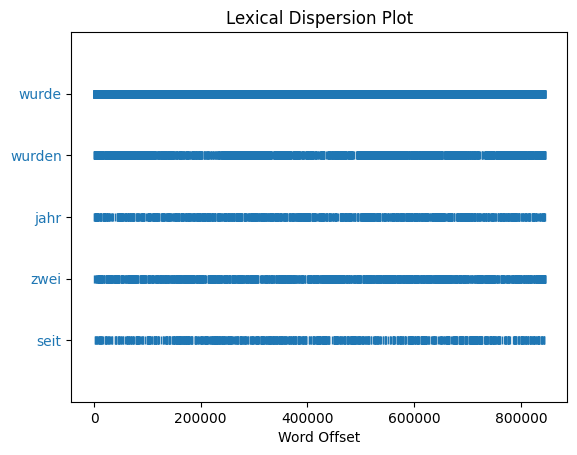

In [81]:
text2=nltk.Text(filter_words)
plot=text2.dispersion_plot([word for word, _ in wordsmc[:5]])


Print a wordcloud without stopwords.

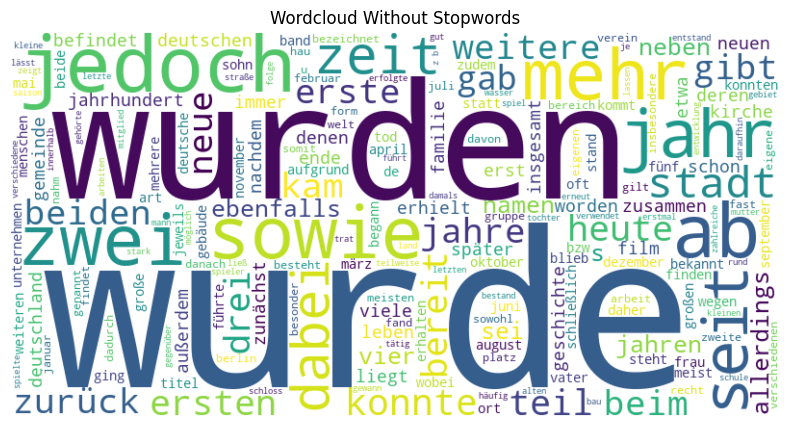

In [82]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(filter_words))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Wordcloud Without Stopwords")
plt.show()